# Exercise 3B

In this exercise, you will explore how the DBSCAN clustering algorithm identifies dense groups and outliers in the Pokémon statistics dataset. You will analyze the dataset, scale features, determine DBSCAN parameters, run DBSCAN, and interpret the clustering results.

In [48]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import numpy as np
from sklearn import metrics
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [ ]:
# Download latest version
path = kagglehub.dataset_download("abcsds/pokemon")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pokemon' dataset.
Path to dataset files: /kaggle/input/pokemon


In [ ]:
if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


## 1. Load the Dataset (8 pts)

Load the Pokémon dataset into a pandas DataFrame.

Show the first five rows (3 pts)

In [214]:
df.head(5)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,cluster
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,0
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,0
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,0
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,0
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,0


In [215]:
# Method 1: Using sum() - counts True values (True = 1, False = 0)
total_legendary = df['Legendary'].sum()
print(f"Total legendary Pokémon: {total_legendary}")



Total legendary Pokémon: 65



How many Pokémon are in the dataset? (2 pts)


In [216]:
df.shape

(800, 14)


List all columns available (3 pts)

In [217]:
df.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary', 'cluster'],
      dtype='object')

## 2: Select Features & Clean the Data (8 pts)

Select the numeric features needed for clustering (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed). (3 pts)

In [195]:
features = ['Sp. Atk', 'Sp. Def', 'HP']
df_num = df[features]
df_num.head()

,Sp. Atk,Sp. Def,HP
0,65,65,45
1,80,80,60
2,100,100,80
3,122,120,80
4,60,50,39


Are there any missing values? (2 pts)

In [192]:
df_num.isnull().sum()

,0
Sp. Atk,0
Sp. Def,0
HP,0


If missing values exist, describe how you handled them (3 pts)

In [173]:
'''
 There are no null values in the chosen features.
'''

'\n There are no null values in the chosen features.\n'

# 3. Scale the Features (10 pts)

Apply StandardScaler to the selected features.

Show the transformed feature sample (e.g., first 5 rows) (10 pts)


In [196]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)
df_scaled = pd.DataFrame(df_scaled, columns=features)
df_scaled.head()

,Sp. Atk,Sp. Def,HP
0,-0.239130,-0.248189,-0.950626
1,0.219560,0.291156,-0.362822
2,0.831146,1.010283,0.420917
3,1.503891,1.729409,0.420917
4,-0.392027,-0.787533,-1.185748


## 4. Determine a Suitable eps Value (10 pts)

Using k = 4:
Compute the distance to the 4th nearest neighbor for each Pokémon (6 pts)

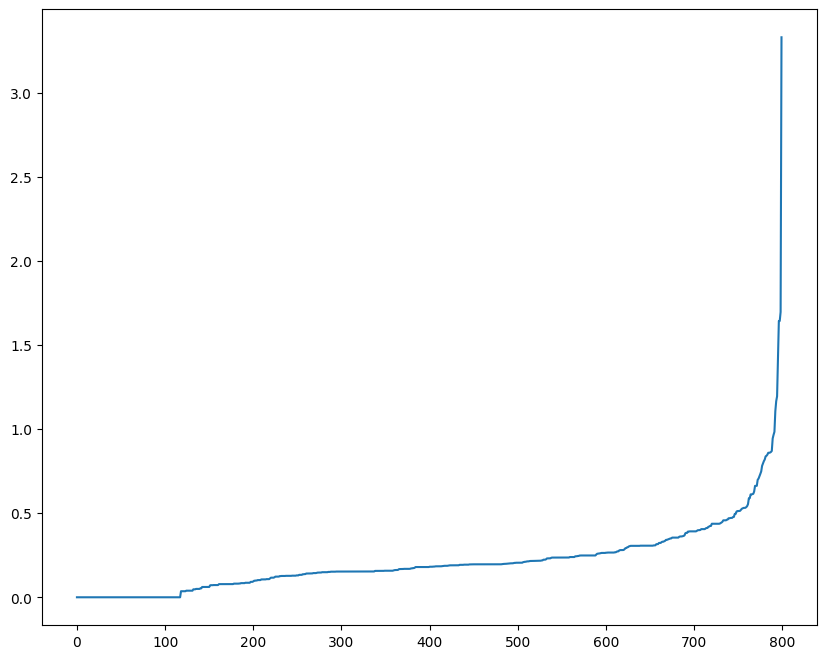

In [197]:
nn = NearestNeighbors(n_neighbors=4).fit(df_scaled)
distances, indices = nn.kneighbors(df_scaled)

distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.figure(figsize=(10,8))
plt.plot(distances)

nn = NearestNeighbors(n_neighbors=4).fit(df_scaled)
distances, indices = nn.kneighbors(df_scaled)

What is your chosen eps based on the "elbow"? (2 pts)

In [46]:
'''
the chosen eps based on the elbow is .4
'''


'\nthe chosen eps based on the elbow is .6\n'

One-sentence explanation of your reasoning (2 pts)

In [43]:
'''
The elbow appears around 0.4 because this is where the 4th-nearest-neighbor distances begin to rise sharply.

'''

'\nThe elbow appears around 0.6 because this is where the 4th-nearest-neighbor distances begin to rise sharply, \nindicating a natural boundary between dense clusters and outliers.\n\n'

## 5. Run DBSCAN (10 points)

Run DBSCAN using your chosen eps and min_samples


How many clusters did DBSCAN find? (4 pts)

In [198]:
min_samples = range(3,5)
epsilon = np.arange(0.4, 0.7, 0.1) # returns array of ranging from 0.05 to 0.13 with step of 0.01
epsilon


array([0.4, 0.5, 0.6])

In [177]:
output = []

for ms in min_samples:
    for ep in epsilon:
        labels = DBSCAN(min_samples=ms, eps = ep).fit(df_scaled).labels_
        score = metrics.silhouette_score(df_scaled, labels)
        output.append((ms, ep, score))

In [199]:
min_samples, eps, score = sorted(output, key=lambda x:x[-1])[-1]
print(f"Best silhouette_score: {score}")
print(f"min_samples: {min_samples}")
print(f"eps: {eps}")

Best silhouette_score: 0.4033211714472191
min_samples: 3
eps: 0.6


In [200]:

ep = eps
dbscan = DBSCAN(eps = ep, min_samples=min_samples).fit(df_scaled)
labels = dbscan.labels_

# Number of clusters in labels
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

# Number of noise
n_noise_ = list(labels).count(-1)

silhouette_score = metrics.silhouette_score(df_scaled, labels)

In [201]:
print("Estimated number of clusters: %d" % n_clusters_)
print("Silhouette scrore", silhouette_score)

Estimated number of clusters: 6
Silhouette scrore 0.049087614145171224


In [203]:
import plotly.express as px
import pandas as pd
from sklearn.cluster import KMeans

fig = px.scatter_3d(df_scaled, x='Sp. Atk', y='Sp. Def', z='HP', color=labels)
fig.show()

How many Pokémon were labeled as noise? (4 pts)

In [218]:
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of noise points: 44


Show the unique labels output by DBSCAN (2 pts)

In [205]:
unique_labels = set(labels)
print(unique_labels)

{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(-1)}


## 6. Attach Cluster Labels to the Original Dataset (7 points)

Add the cluster labels back to the original DataFrame (3 pts)

In [208]:
df['cluster'] = labels

Show the first 10 rows including the cluster label (4 pts)

In [219]:
df.head(10)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,cluster
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,0
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,0
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,0
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,0
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,0
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False,0
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False,0
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False,0
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False,1
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False,0


## 7. Explore the Clusters (12 points)

For each cluster:


How many Pokémon does it contain? (4 pts)

In [220]:
cluster_counts = df['cluster'].value_counts().sort_index()
print("Pokémon count per cluster:")
print(cluster_counts)
print(f"\nCluster 0: {cluster_counts[0]} Pokémon")
print(f"Noise (Cluster -1): {cluster_counts[-1]} Pokémon")

Pokémon count per cluster:
cluster
-1     44
 0    733
 1      8
 2      3
 3      6
 4      3
 5      3
Name: count, dtype: int64

Cluster 0: 733 Pokémon
Noise (Cluster -1): 44 Pokémon


What are the average Attack, Defense, and Speed? (4 pts)


In [221]:
# Average Attack, Defense, and Speed for each cluster
cluster_stats = df.groupby('cluster')[['Attack', 'Defense', 'Speed']].mean()
print("\nAverage stats by cluster:")
print(cluster_stats)


Average stats by cluster:
             Attack     Defense      Speed
cluster                                   
-1        86.318182   74.727273  74.409091
 0        77.649386   73.081855  67.482947
 1       115.500000   83.500000  86.875000
 2       106.666667   75.666667  77.666667
 3       130.000000  110.833333  98.333333
 4        50.666667  156.000000  46.666667
 5       103.333333   63.000000  75.000000


Compare the clusters: What differences do you notice? (4 pts)

In [222]:
'''
Cluster 3 has the highest Attack and Speed while CLuster 4 has the highest Defense.
'''

'\nCluster 3 has the highest Attack and Speed while CLuster 4 has the highest Defense.\n'

## 8. Identify Outliers (10 points)

List all Pokémon labeled as noise (cluster = -1) (4 pts)

In [223]:
df[df['cluster'] == -1]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,cluster
44,39,Jigglypuff,Normal,Fairy,270,115,45,20,45,25,20,1,False,-1
71,65,AlakazamMega Alakazam,Psychic,NaN,590,55,50,65,175,95,150,1,False,-1
99,92,Gastly,Ghost,Poison,310,30,35,30,100,35,80,1,False,-1
102,94,GengarMega Gengar,Ghost,Poison,600,60,65,80,170,95,130,1,False,-1
121,113,Chansey,Normal,NaN,450,250,5,5,35,105,50,1,False,-1
131,122,Mr. Mime,Psychic,Fairy,460,40,45,65,100,120,90,1,False,-1
155,143,Snorlax,Normal,NaN,540,160,110,65,65,110,30,1,False,-1
164,150,MewtwoMega Mewtwo Y,Psychic,NaN,780,106,150,70,194,120,140,1,True,-1
188,174,Igglybuff,Normal,Fairy,210,90,30,15,40,20,15,2,False,-1
217,202,Wobbuffet,Psychic,NaN,405,190,33,58,33,58,33,2,False,-1


Are many of them legendary? (3 pts)

In [227]:
df[df['cluster'] == -1]['Legendary'].value_counts()

,count
Legendary,
False,27
True,17


Explain why DBSCAN might classify them as outliers (3 pts)

In [225]:
'''
DBSCAN classifies points as outliers (noise, labeled as -1) if they do not have at least `min_samples`
neighbors within the `eps` radius. This means these Pokémon are in the farther areas of the feature space (Sp. Atk, Sp. Def, HP) and do not
belong to any dense cluster identified by the algorithm.
'''

'\nDBSCAN classifies points as outliers (noise, labeled as -1) if they do not have at least `min_samples` \nneighbors within the `eps` radius. This means these Pokémon are in the farther areas of the feature space (Sp. Atk, Sp. Def, HP) and do not \nbelong to any dense cluster identified by the algorithm.\n'

## 9. Interpret the Clustering Results (25 points)
Write a short interpretation (4–6 sentences).
Discuss:


What types of Pokémon grouped together (5 pts)

In [ ]:
'''
- Cluster 0 is the largest and represents the majority of Pokémon with average stats.")
- Cluster 3 stands out with the highest average Attack and Speed, suggesting powerful and fast Pokémon.")
- Cluster 4 has a remarkably high average Defense, indicating very tanky Pokémon.")
- other clusters (1, 2, 5) represent smaller, distinct groups with varying stat distributions, though not as extreme as clusters 3 and 4.")
- Noise points (Cluster -1) are diverse in their individual stats, but as a group, their averages are around the dataset's overall mean,
  suggesting they are outliers not because of extreme stats in one direction, but because they don't form dense groups with others.")
'''

Whether the clusters make intuitive sense (10 pts)

In [ ]:
'''
Yes, the clusters make sense because they show the grouped Pokémon with similar stats showing where they are good at.
For example, Cluster 3 has the highest Attack and Speed meaning they are good attackers while Cluster 4 has the highest Defense meaning they are good defenders.
and the other Clusters being your average/typical Pokémon.
'''


What the noise points reveal about DBSCAN (5 pts)


In [ ]:
'''
The noise points show objects that are outside of the dense clusters.
this can mean that maybe the eps is too small or the min_samples is too large.
'''


What stat patterns you discovered (5 pts)

In [ ]:
'''
The analysis revealed several clear stat patterns: most Pokémon are average with balanced average stats forming the largest cluster,
while distinct, smaller clusters emerge for specialized roles, one for powerful physical attackers (high Attack and Speed)
and another for defensive tanks (high Defense). This shows a natural offensive defensive.
The noise points, despite having near-average individual stats, are outliers due to unconventional stat combinations that don't align with these dense,
role-defined groupings.